In [78]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset,Subset
import torchvision
from torchvision import transforms,datasets,models
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [66]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [67]:
BATCH_SIZE = 12
IMG_SIZE = 28
PATCH_SIZE = 7
ATTN_HEADS = 4
TRANSFORMER_LAYERS = 4
EMBED_DIM = 32
CLASSES = 10
EPOCHS_STUDENTS = 5
LR_STUDENT = 3e-4
CHANNELS = 3
TEMPERATURE = 2
ALPHA = 0.5 # FOR KL DIVERGENCE loss

In [68]:
data_transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.repeat(3,1,1))
    ])

train_ds_full = datasets.MNIST('./data',train=True,download=True,transform=data_transformation)
val_ds = datasets.MNIST('./data',train=True,download=True,transform=data_transformation)


In [69]:
n = int(0.1*len(train_ds_full))
subset_idx = np.random.permutation(len(train_ds_full))[:n]
train_ds = Subset(train_ds_full,subset_idx)


train_dl = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_dl = DataLoader(val_ds,batch_size=BATCH_SIZE)

In [70]:
teacher = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
teacher.fc = nn.Linear(teacher.fc.in_features,CLASSES)
teacher.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [71]:
class PatchEmbed(nn.Module):
    def __init__(self,channels = CHANNELS,embed_dim = EMBED_DIM,patch_size = PATCH_SIZE,img_size = IMG_SIZE):
        super().__init__()
        self.proj = nn.Conv2d(in_channels=channels,out_channels=embed_dim,kernel_size=patch_size,stride=patch_size)
        self.n = (img_size // patch_size)**2

    def forward(self,x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1,2)

        return x
    

In [72]:
import torch
import torch.nn as nn

class ViT(nn.Module):

    def __init__(self, classes=CLASSES, embed_dim=EMBED_DIM, attn_head=ATTN_HEADS, layers=TRANSFORMER_LAYERS):
        super().__init__()

        self.patch_embed = PatchEmbed()

        self.cls = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.distil = nn.Parameter(torch.zeros(1,1,embed_dim))

        n = self.patch_embed.n

        self.position = nn.Parameter(torch.zeros(1,n+2,embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=attn_head,
            dim_feedforward=embed_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers
        )

        self.layernorm = nn.LayerNorm(embed_dim)

        self.head_cls = nn.Linear(embed_dim, classes)
        self.head_distil = nn.Linear(embed_dim, classes)

    def forward(self, x):

        B = x.shape[0]

        x = self.patch_embed(x)

        cls = self.cls.expand(B, -1, -1)
        dist = self.distil.expand(B, -1, -1)

        x = torch.cat([cls, x, dist], dim=1)

        x = x + self.position

        x = self.transformer(x)

        x = self.layernorm(x)

        cls_token = x[:,0]
        distil_token = x[:,-1]

        cls_logits = self.head_cls(cls_token)
        distil_logits = self.head_distil(distil_token)

        return cls_logits, distil_logits

In [73]:
student = ViT().to(device)
opt_s = torch.optim.AdamW(student.parameters(),lr=LR_STUDENT)

In [74]:
def kd_loss(cls_logits,distil_logits,t_logits,y,alpha = ALPHA,temperature = TEMPERATURE):
    kd = F.kl_div(
        F.log_softmax(distil_logits / temperature, dim=-1),
        F.softmax(t_logits / temperature, dim=-1),
        reduction='batchmean'
    ) * (temperature ** 2)
    ce = F.cross_entropy(cls_logits,y)
    return alpha*kd + (1-alpha)*ce

In [75]:
for e in range(1,EPOCHS_STUDENTS+1):
    student.train()
    for x,y in train_dl:
        x,y = x.to(device),y.to(device)
        with torch.no_grad():
            t_logits = teacher(x)
        cls_logits,distil_logits = student(x)
        loss = kd_loss(cls_logits,distil_logits,t_logits,y)
        opt_s.zero_grad()
        loss.backward()
        opt_s.step()
    print(f"Epoch {e} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [82]:
student.eval()
correct =0;total = 0
samples = []

with torch.no_grad():
    
    for x,y in val_dl:
        x,y = x.to(device),y.to(device)
        with torch.no_grad():
            t_logits = teacher(x)
        cls_logits,distil_logits = student(x)
        cls_dist = (cls_logits+distil_logits)/2
        pred = cls_logits.argmax(-1)
        correct+= (pred == y).sum().item(); total += y.size(0)
        if len(samples)<5:
            samples.append((x.cpu(),pred.cpu(),y.cpu()))
    acc = 100*correct/total
    print(f"Validation Accuraccy: {acc:.2f}%")

Validation Accuraccy: 84.92%


<class 'torch.Tensor'> <class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>


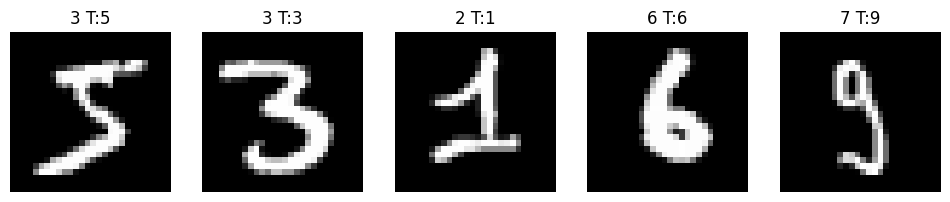

In [85]:
fig,axs = plt.subplots(1,len(samples),figsize=(12,3))
for i,(img,pred,true) in enumerate(samples):
    print(type(pred), type(true))
    img = (img[0].permute(1,2,0).cpu().numpy())
    axs[i].imshow(img)
    axs[i].set_title(f"{pred[0].item()} T:{true[0].item()}")
    axs[i].axis('off')

plt.show()